In [1]:
import pandas as pd
import numpy as np
df = pd.read_csv("Wellbeing_and_lifestyle_data_Kaggle (Dataset1).csv")

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15972 entries, 0 to 15971
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Timestamp                15972 non-null  str    
 1   FRUITS_VEGGIES           15972 non-null  int64  
 2   DAILY_STRESS             15972 non-null  str    
 3   PLACES_VISITED           15972 non-null  int64  
 4   CORE_CIRCLE              15972 non-null  int64  
 5   SUPPORTING_OTHERS        15972 non-null  int64  
 6   SOCIAL_NETWORK           15972 non-null  int64  
 7   ACHIEVEMENT              15972 non-null  int64  
 8   DONATION                 15972 non-null  int64  
 9   BMI_RANGE                15972 non-null  int64  
 10  TODO_COMPLETED           15972 non-null  int64  
 11  FLOW                     15972 non-null  int64  
 12  DAILY_STEPS              15972 non-null  int64  
 13  LIVE_VISION              15972 non-null  int64  
 14  SLEEP_HOURS              15972 no

In [3]:
for col in df.columns[1:]:
    print(f"The unique values in {col}: {df[col].unique()}\n")

The unique values in FRUITS_VEGGIES: [3 2 5 4 1 0]

The unique values in DAILY_STRESS: <StringArray>
['2', '3', '1', '4', '5', '0', '01-01-2000']
Length: 7, dtype: str

The unique values in PLACES_VISITED: [ 2  4  3 10  5  6  7  0  8  1  9]

The unique values in CORE_CIRCLE: [ 5  3  4  9  6  7  8 10  2  1  0]

The unique values in SUPPORTING_OTHERS: [ 0  8  4 10  5  3  1  2  6  7  9]

The unique values in SOCIAL_NETWORK: [ 5 10  7  4  3  1  2  8  6  9  0]

The unique values in ACHIEVEMENT: [ 2  5  3  4  0  1  6 10  8  7  9]

The unique values in DONATION: [0 2 5 4 3 1]

The unique values in BMI_RANGE: [1 2]

The unique values in TODO_COMPLETED: [ 6  5  2  3  8 10  7  4  1  0  9]

The unique values in FLOW: [ 4  2  5  0  1  8  7  6  3 10  9]

The unique values in DAILY_STEPS: [ 5  4  7  8  1  3  6  2 10  9]

The unique values in LIVE_VISION: [ 0  5 10  4  2  1  6  3  8  9  7]

The unique values in SLEEP_HOURS: [ 7  8  5  6 10  9  4  3  2  1]

The unique values in LOST_VACATION: [ 5  2 1

<Axes: title={'center': 'SLEEP_HOURS vs DAILY_STEPS'}, ylabel='Frequency'>

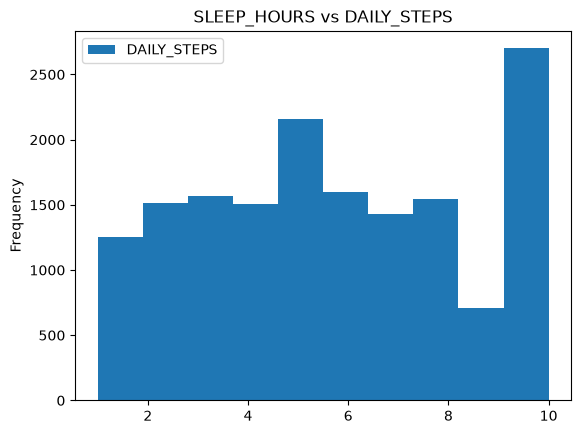

In [4]:
#Removing wrong value
df = df[df['DAILY_STRESS'] != '01-01-2000']
df['DAILY_STRESS'] = df['DAILY_STRESS'].astype("int64")

#Encoding age and gender
df['AGE_GROUP']  = df['AGE'].map({ "Less than 20": 0, "21 to 35": 1, "36 to 50": 2, "51 or more": 3 })
df = pd.get_dummies(df, columns=['GENDER'], drop_first=True)
df.drop(columns=['Timestamp'], inplace=True)


df["SLEEP_HOURS"].corr(df["DAILY_STEPS"])
df.sort_values(by="SLEEP_HOURS", ascending=False,inplace=True)
df.plot(x="SLEEP_HOURS", y="DAILY_STEPS", kind="hist", title="SLEEP_HOURS vs DAILY_STEPS")

In [5]:
df.info()

<class 'pandas.DataFrame'>
Index: 15971 entries, 60 to 4763
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   FRUITS_VEGGIES           15971 non-null  int64  
 1   DAILY_STRESS             15971 non-null  int64  
 2   PLACES_VISITED           15971 non-null  int64  
 3   CORE_CIRCLE              15971 non-null  int64  
 4   SUPPORTING_OTHERS        15971 non-null  int64  
 5   SOCIAL_NETWORK           15971 non-null  int64  
 6   ACHIEVEMENT              15971 non-null  int64  
 7   DONATION                 15971 non-null  int64  
 8   BMI_RANGE                15971 non-null  int64  
 9   TODO_COMPLETED           15971 non-null  int64  
 10  FLOW                     15971 non-null  int64  
 11  DAILY_STEPS              15971 non-null  int64  
 12  LIVE_VISION              15971 non-null  int64  
 13  SLEEP_HOURS              15971 non-null  int64  
 14  LOST_VACATION            15971 non-nul

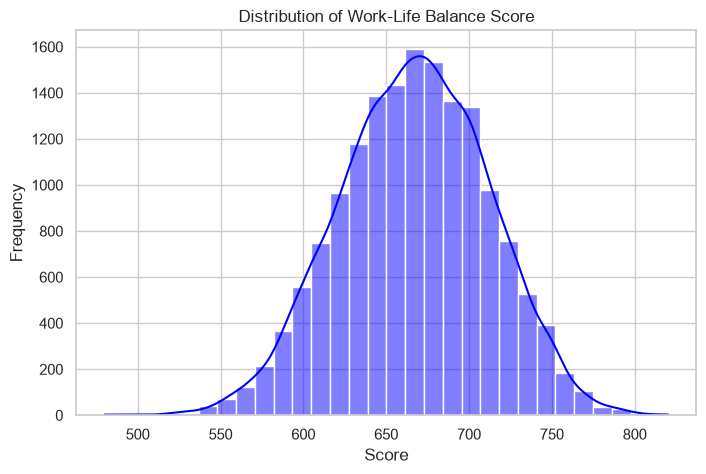

C:\Users\adity\AppData\Local\Temp\ipykernel_12812\3895421112.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='SLEEP_HOURS', y='WORK_LIFE_BALANCE_SCORE', data=df, palette='Set2')


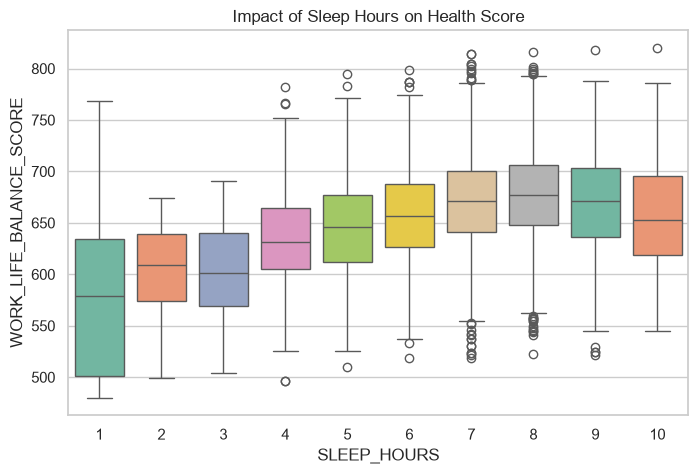

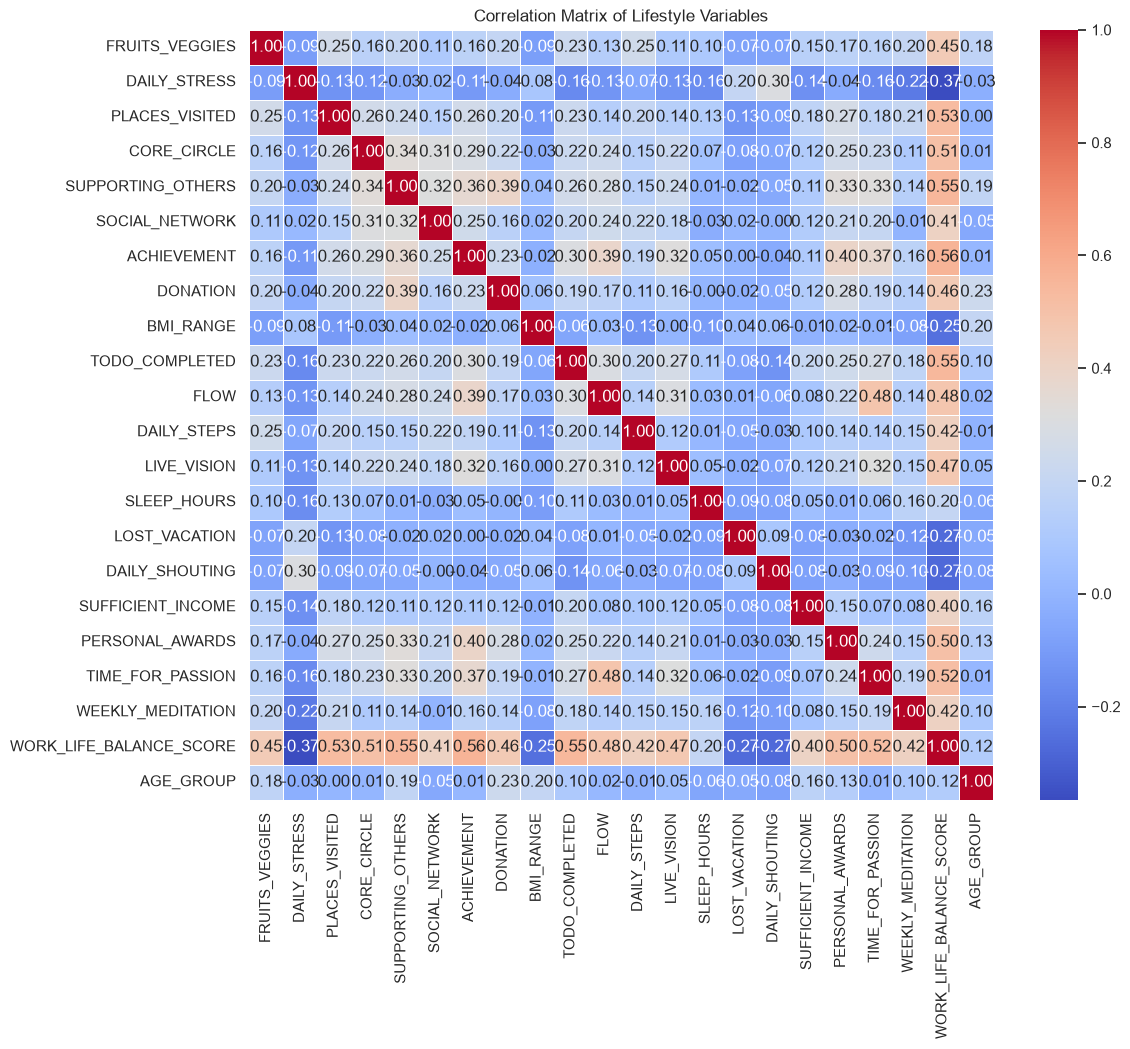

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set aesthetic style
sns.set_theme(style="whitegrid")

# 1. Univariate: Distribution of the Target Variable
plt.figure(figsize=(8, 5))
sns.histplot(df['WORK_LIFE_BALANCE_SCORE'], bins=30, kde=True, color='blue')
plt.title('Distribution of Work-Life Balance Score')
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.show()

# 2. Bivariate: Sleep vs. Health Score
plt.figure(figsize=(8, 5))
sns.boxplot(x='SLEEP_HOURS', y='WORK_LIFE_BALANCE_SCORE', data=df, palette='Set2')
plt.title('Impact of Sleep Hours on Health Score')
plt.show()

# 3. Multivariate: Correlation Heatmap (Numeric only)
plt.figure(figsize=(12, 10))
numeric_df = df.select_dtypes(include=['int64', 'float64'])
correlation_matrix = numeric_df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Lifestyle Variables')
plt.show()

In [7]:
df.head()

,FRUITS_VEGGIES,DAILY_STRESS,PLACES_VISITED,CORE_CIRCLE,SUPPORTING_OTHERS,SOCIAL_NETWORK,ACHIEVEMENT,DONATION,BMI_RANGE,TODO_COMPLETED,...,LOST_VACATION,DAILY_SHOUTING,SUFFICIENT_INCOME,PERSONAL_AWARDS,TIME_FOR_PASSION,WEEKLY_MEDITATION,AGE,WORK_LIFE_BALANCE_SCORE,AGE_GROUP,GENDER_Male
60,0,5,0,2,1,2,1,5,1,1,...,0,2,1,1,0,0,21 to 35,575.3,1,True
59,0,5,0,2,1,2,0,5,1,0,...,0,2,1,1,0,0,21 to 35,571.9,1,True
5634,1,3,2,4,4,2,2,0,1,0,...,0,2,2,2,2,7,Less than 20,628.2,0,False
5836,4,5,10,10,6,10,1,3,1,5,...,10,3,2,2,1,10,Less than 20,680.8,0,False
5550,2,0,7,4,8,1,7,1,1,8,...,0,0,1,4,9,10,36 to 50,704.7,2,True


C:\Users\adity\AppData\Local\Temp\ipykernel_12812\2736600704.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[feature], y=df[target], palette="viridis")
C:\Users\adity\AppData\Local\Temp\ipykernel_12812\2736600704.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[feature], y=df[target], palette="viridis")
C:\Users\adity\AppData\Local\Temp\ipykernel_12812\2736600704.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[feature], y=df[target], palette="viridis")
C:\Users\adity\AppData\Local\Temp\ipykernel_12812\2736600704.

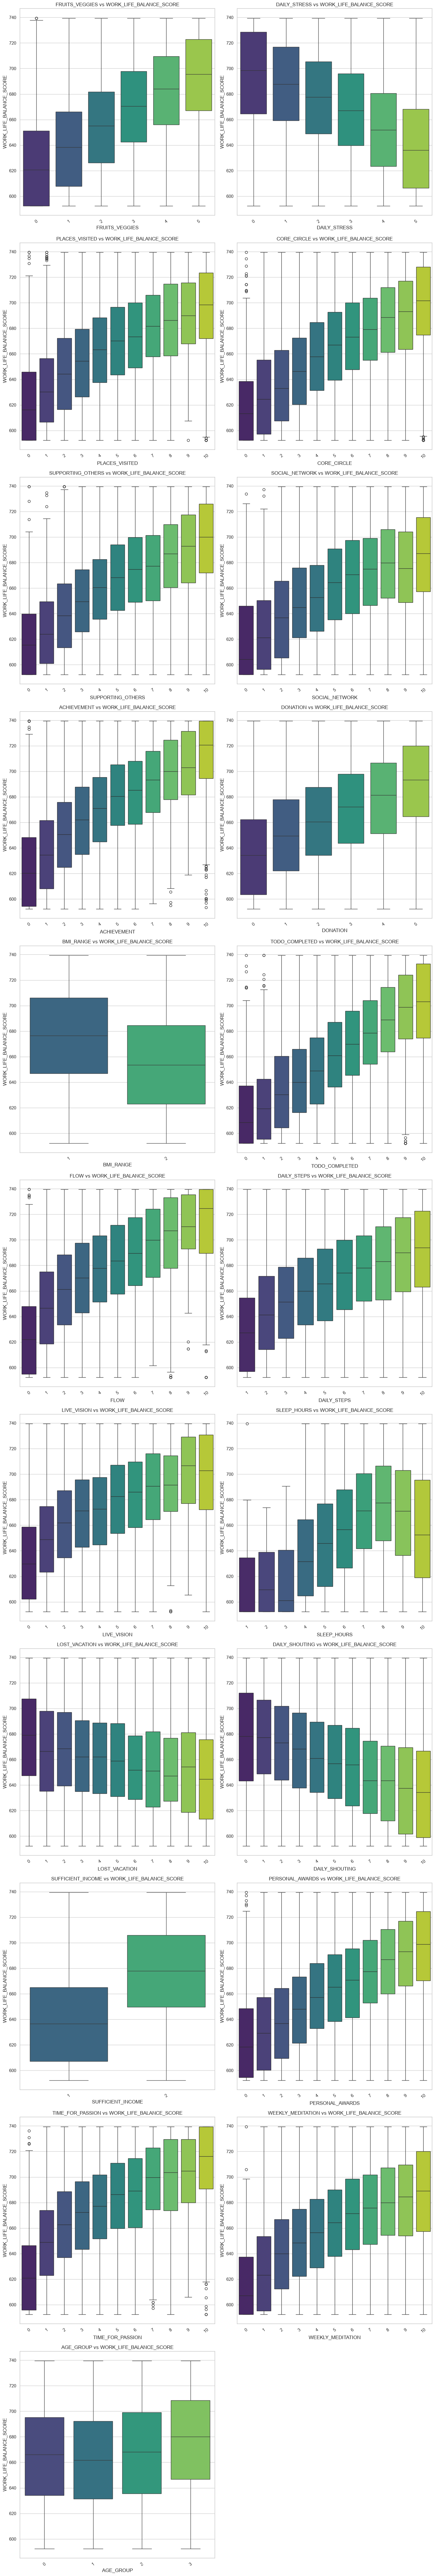

In [8]:
# import matplotlib.pyplot as plt
# import seaborn as sns
# import pandas as pd
from scipy.stats import mstats

# Assuming 'df' is your cleaned dataframe BEFORE scaling
# and 'target' is your target column name
target = 'WORK_LIFE_BALANCE_SCORE'

# Get list of numerical features (excluding the target)
# We filter out the one-hot encoded categorical columns if you want to focus on continuous metrics
# OR include them if you want to see the impact of categories (like Age groups)
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns.drop(target)

# Create a grid of plots
n_cols = 2
n_rows = (len(numerical_features) + n_cols - 1) // n_cols



# Caps bottom 5% and top 5% — no data lost
df[target] = mstats.winsorize(df[target], limits=[0.05,0.05])

plt.figure(figsize=(15, 8 * n_rows))

for i, feature in enumerate(numerical_features):
    plt.subplot(n_rows, n_cols, i+1)
    
    # Create a boxplot
    sns.boxplot(x=df[feature], y=df[target], palette="viridis")
    plt.title(f'{feature} vs {target}')
    plt.xlabel(feature)
    plt.ylabel(target)
    plt.xticks(rotation=35)

plt.tight_layout()
plt.show()

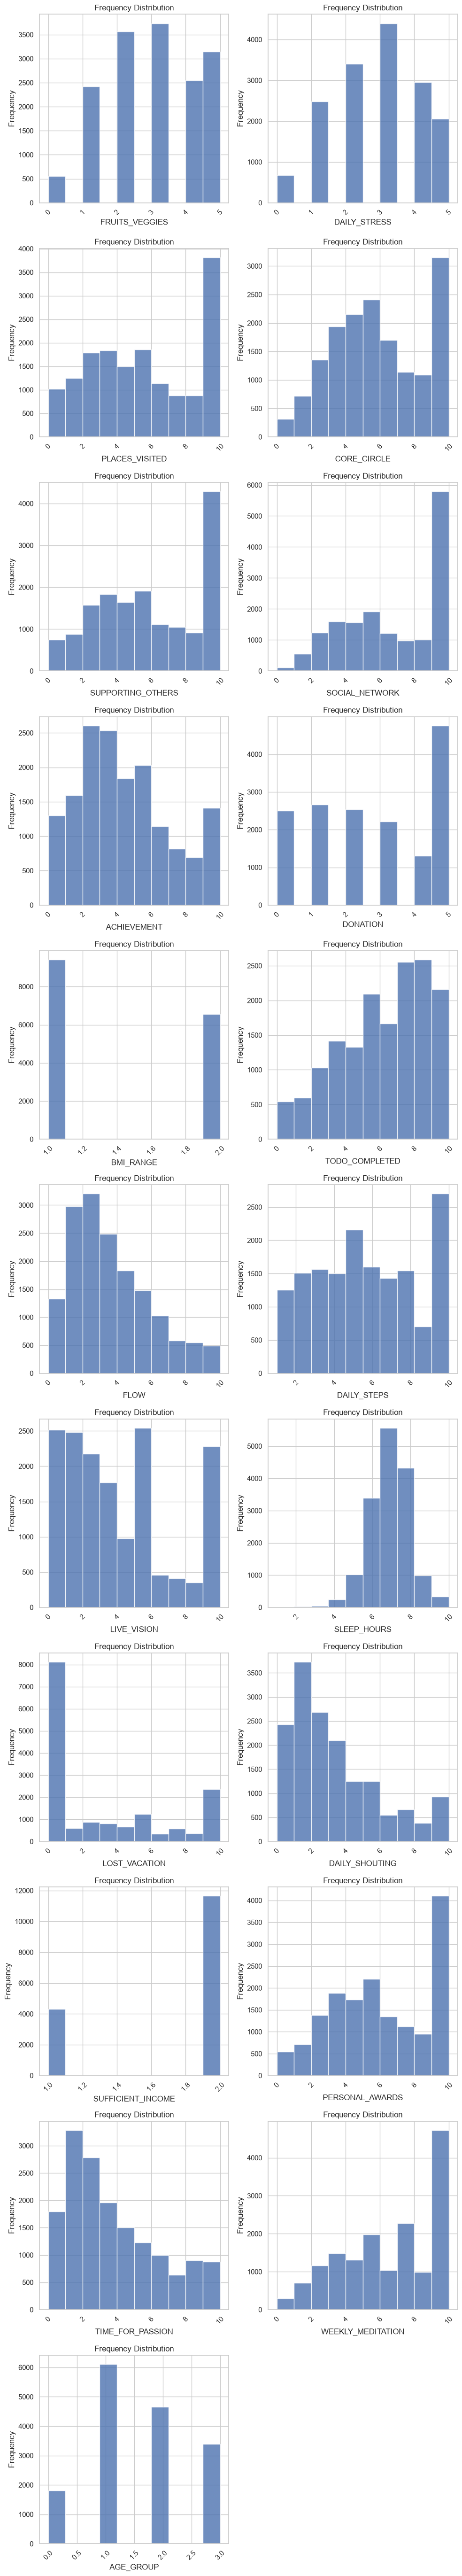

In [9]:
target = 'WORK_LIFE_BALANCE_SCORE'

# Get list of numerical features (excluding the target)
# We filter out the one-hot encoded categorical columns if you want to focus on continuous metrics
# OR include them if you want to see the impact of categories (like Age groups)
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns.drop(target)

# Create a grid of plots
n_cols = 2
n_rows = (len(numerical_features) + n_cols - 1) // n_cols

plt.figure(figsize=(10, 5 * n_rows))

for i, feature in enumerate(numerical_features):
    plt.subplot(n_rows, n_cols, i+1)
    
    # Create a hist
    plt.hist(df[feature], bins=10, alpha=0.8, label=feature)
    plt.title('Frequency Distribution')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [10]:
df = df[df['DAILY_STRESS'] != '01-01-2000']
df['DAILY_STRESS'] = df['DAILY_STRESS'].astype(int)
# 1. Engineer: Psychological Stress Load
# Higher score = Worse psychological regulation
df['PSYCH_STRESS_LOAD'] = df['DAILY_STRESS'] + df['DAILY_SHOUTING'] - df['WEEKLY_MEDITATION']

# 2. Engineer: Social Isolation Index
# We invert the sum so that a HIGHER score means MORE isolation
# Added +1 to denominator to prevent division by zero
df['SOCIAL_ISOLATION_INDEX'] = 1 / (df['CORE_CIRCLE'] + df['SOCIAL_NETWORK'] + 1)

# 3. Engineer: Metabolic Risk Proxy
# High BMI combined with low steps. 
# Added +1 to steps to prevent division by zero (if a user has 0 steps)
# Note: Adjust 'BMI_RANGE' to whatever your specific column name is after dummy encoding
df['METABOLIC_RISK_PROXY'] = df['BMI_RANGE'] / (df['DAILY_STEPS'] + 1)

df['SATISFACTION_SCORE'] = df['SUFFICIENT_INCOME'] + df['TIME_FOR_PASSION'] - df['LOST_VACATION']

# 4. Check for Multicollinearity in the new feature set
print("Checking correlations of engineered features with the target:")
new_features = ['PSYCH_STRESS_LOAD', 'SOCIAL_ISOLATION_INDEX', 'METABOLIC_RISK_PROXY','SATISFACTION_SCORE', 'WORK_LIFE_BALANCE_SCORE']
print(df[new_features].corr()['WORK_LIFE_BALANCE_SCORE'])

Checking correlations of engineered features with the target:
PSYCH_STRESS_LOAD         -0.497855
SOCIAL_ISOLATION_INDEX    -0.411757
METABOLIC_RISK_PROXY      -0.421724
SATISFACTION_SCORE         0.540949
WORK_LIFE_BALANCE_SCORE    1.000000
Name: WORK_LIFE_BALANCE_SCORE, dtype: float64


In [11]:
df[new_features]

,PSYCH_STRESS_LOAD,SOCIAL_ISOLATION_INDEX,METABOLIC_RISK_PROXY,SATISFACTION_SCORE,WORK_LIFE_BALANCE_SCORE
60,7,0.200000,0.500000,1,592.3
59,7,0.200000,0.500000,1,592.3
5634,-2,0.142857,0.333333,4,628.2
5836,-2,0.047619,0.090909,-7,680.8
5550,-10,0.166667,0.333333,10,704.7
...,...,...,...,...,...
6299,5,0.083333,0.500000,1,592.3
3376,15,1.000000,1.000000,-9,592.3
9987,0,1.000000,0.500000,1,592.3
14255,4,0.076923,1.000000,3,604.1


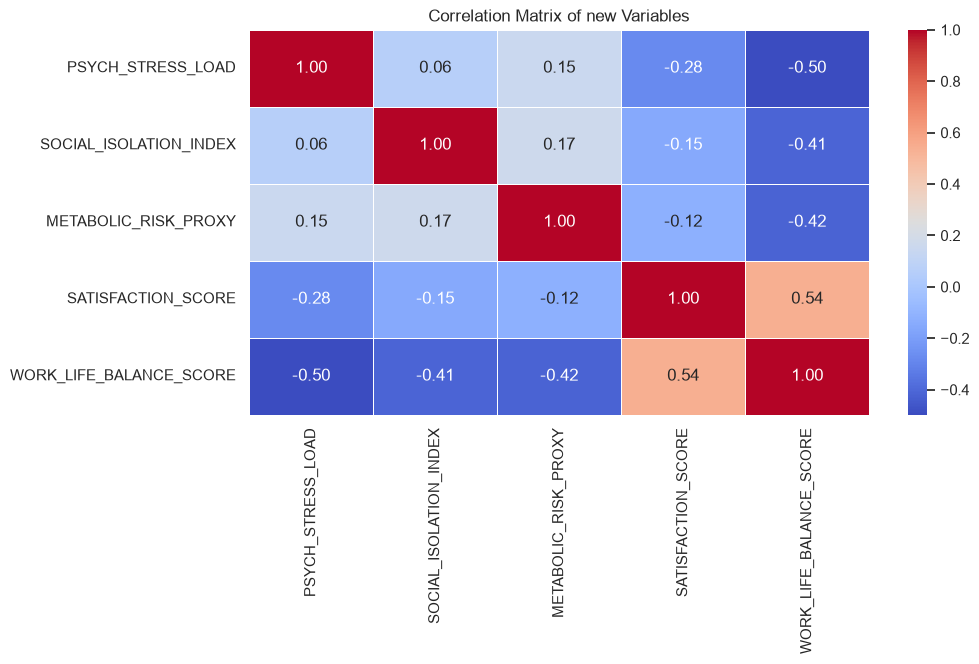

In [12]:
plt.figure(figsize=(10, 5))
correlation_matrix = df[new_features].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of new Variables')
plt.show()

C:\Users\adity\AppData\Local\Temp\ipykernel_12812\1734066379.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[feature], y=df[target], palette="viridis")


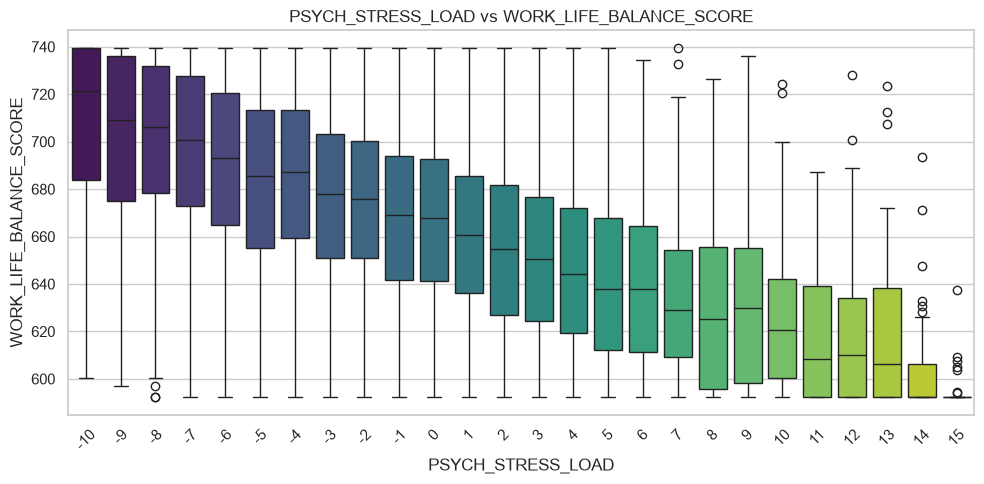

C:\Users\adity\AppData\Local\Temp\ipykernel_12812\1734066379.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[feature], y=df[target], palette="viridis")


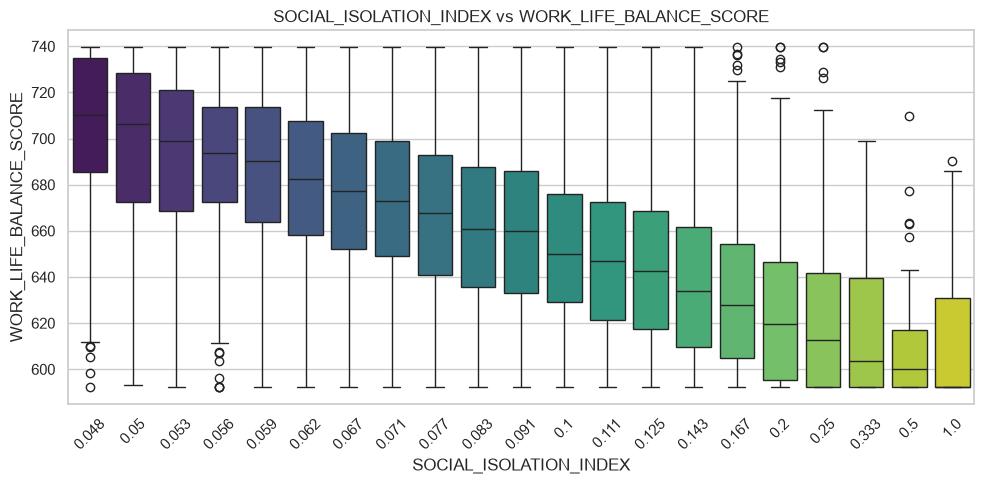

C:\Users\adity\AppData\Local\Temp\ipykernel_12812\1734066379.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[feature], y=df[target], palette="viridis")


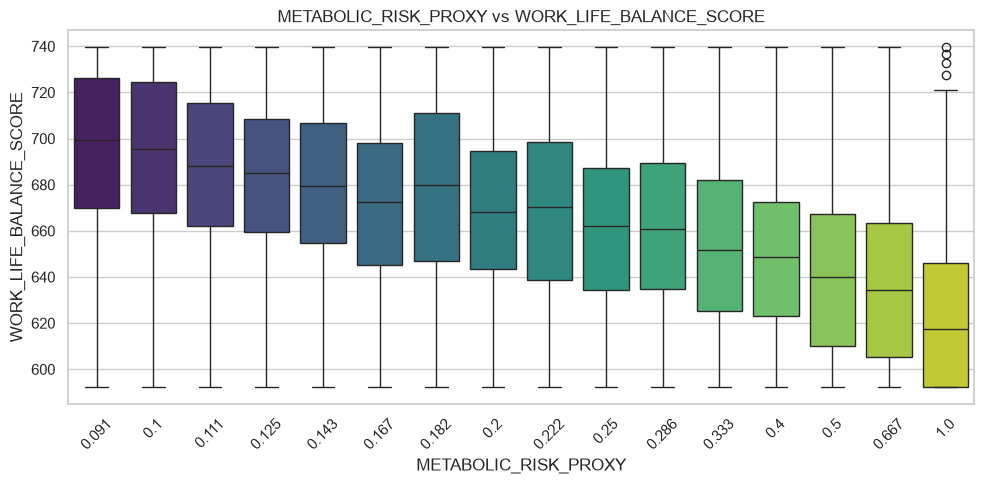

C:\Users\adity\AppData\Local\Temp\ipykernel_12812\1734066379.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[feature], y=df[target], palette="viridis")


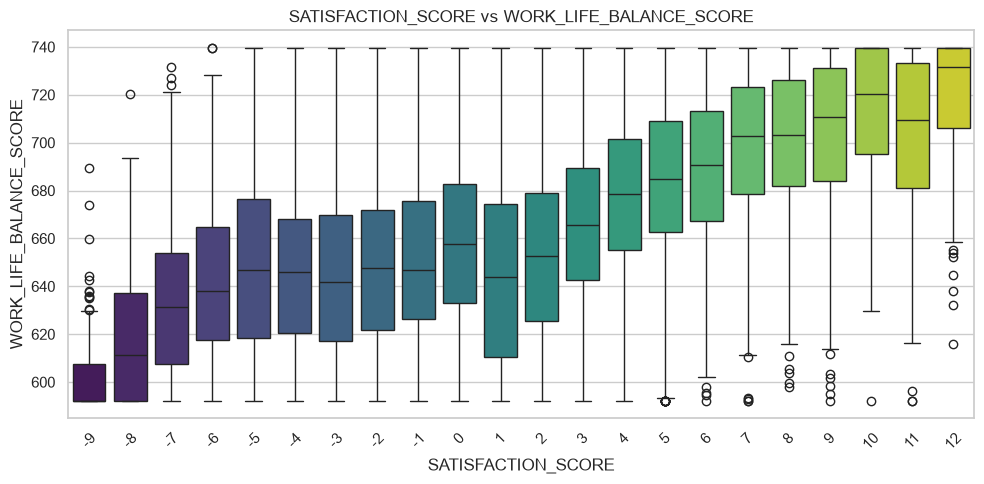

In [13]:
df['METABOLIC_RISK_PROXY'] = df['METABOLIC_RISK_PROXY'].round(3)  # Round for better visualization
df['SOCIAL_ISOLATION_INDEX'] = df['SOCIAL_ISOLATION_INDEX'].round(3)  # Round for better visualization
for i, feature in enumerate(new_features[:-1]):  # Exclude the target from the loop
    plt.figure(figsize=(10, 5))
    sns.boxplot(x=df[feature], y=df[target], palette="viridis")
    plt.title(f'{feature} vs {target}')
    plt.xlabel(feature)
    plt.ylabel(target)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [14]:
df.drop(columns=['AGE','BMI_RANGE','DAILY_STEPS','CORE_CIRCLE','SOCIAL_NETWORK','DAILY_STRESS','DAILY_SHOUTING','WEEKLY_MEDITATION','SUFFICIENT_INCOME','TIME_FOR_PASSION','LOST_VACATION'],inplace=True)

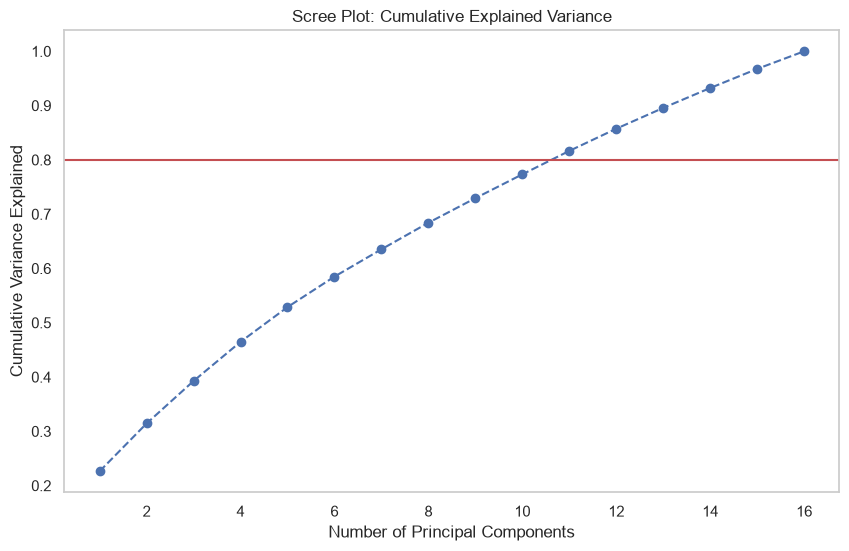


--- Feature importance in Principal Component 1 ---
ACHIEVEMENT          0.338991
SUPPORTING_OTHERS    0.331692
TODO_COMPLETED       0.311782
dtype: float64
METABOLIC_RISK_PROXY     -0.169985
PSYCH_STRESS_LOAD        -0.216814
SOCIAL_ISOLATION_INDEX   -0.250630
dtype: float64


In [15]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Assuming 'X' is your dataframe of features (excluding the target variable)
# 1. Standardize the data (PCA requires this strictly)

X = df.drop(columns=['WORK_LIFE_BALANCE_SCORE'])
y = df['WORK_LIFE_BALANCE_SCORE']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# 2. Fit PCA on all components to see variance distribution
pca_full = PCA()
pca_full.fit_transform(X_scaled)

# 3. Calculate Explained Variance
explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# 4. Plot the Scree Plot
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_variance) + 1), cumulative_variance, marker='o', linestyle='--')
plt.axhline(y=0.80, color='r', linestyle='-') # 80% variance threshold
plt.title('Scree Plot: Cumulative Explained Variance')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Variance Explained')
plt.grid()
plt.show()

# 5. Extract feature weights for PC1 to see what it represents
pc1_weights = pd.Series(pca_full.components_[0], index=X.columns).sort_values(ascending=False)
print("\n--- Feature importance in Principal Component 1 ---")
print(pc1_weights.head(3)) # Top 3 positive contributors
print(pc1_weights.tail(3)) # Top 3 negative contributors

In [16]:
print(pca_full.components_[0])

[ 0.23884806  0.27465815  0.33169215  0.33899083  0.26802944  0.31178198
  0.29106465  0.26411706  0.08417179  0.30081171  0.10448202 -0.05427816
 -0.21681367 -0.25062963 -0.16998456  0.26249283]


In [17]:
pca_full

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized S

In [18]:
PCA_DF = pd.DataFrame(data = pca_full.transform(X_scaled)[:, :3], columns=['PC1', 'PC2', 'PC3'])
PCA_DF['Target'] = y.values

print(PCA_DF.head(3))
print(PCA_DF.tail(3))

        PC1       PC2       PC3  Target
0 -4.043307 -0.342330  0.279727   592.3
1 -4.285131 -0.307239  0.381272   592.3
2 -2.541324 -1.995243  0.158697   628.2
            PC1       PC2       PC3  Target
15968 -8.144977  1.961736  1.341486   592.3
15969 -1.730670  3.431824 -4.053204   604.1
15970 -9.994723  3.272991 -0.666171   592.3


Variance explained by PC1: 22.64%
Variance explained by PC2: 8.80%
Total variance captured in this 2D plot: 31.44%


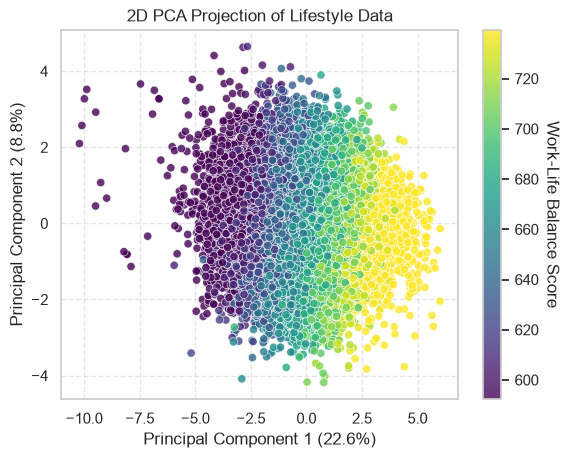

In [19]:
var_explained = pca_full.explained_variance_ratio_
print(f"Variance explained by PC1: {var_explained[0]*100:.2f}%")
print(f"Variance explained by PC2: {var_explained[1]*100:.2f}%")
print(f"Total variance captured in this 2D plot: {(var_explained[0]+var_explained[1])*100:.2f}%")
scatter = plt.scatter(PCA_DF['PC1'], PCA_DF['PC2'], c=PCA_DF['Target'], cmap='viridis', 
                      alpha=0.8, # Make dots slightly transparent to see overlapping
                      edgecolors='w', 
                      linewidth=0.5)

# Add a color bar to explain the colors
cbar = plt.colorbar(scatter)
cbar.set_label('Work-Life Balance Score', rotation=270, labelpad=15)

# Labels and Title
plt.xlabel(f'Principal Component 1 ({var_explained[0]*100:.1f}%)')
plt.ylabel(f'Principal Component 2 ({var_explained[1]*100:.1f}%)')
plt.title('2D PCA Projection of Lifestyle Data')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

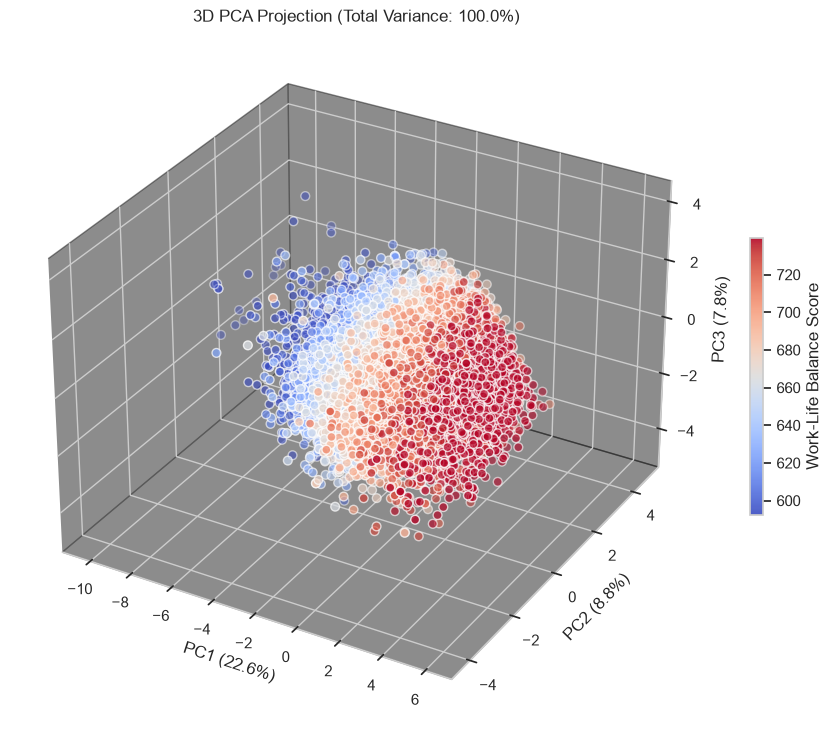

In [29]:
# Plot 3D
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot
scatter = ax.scatter(PCA_DF['PC1'], PCA_DF['PC2'], PCA_DF['PC3'], 
                     c=PCA_DF['Target'], cmap='coolwarm', 
                     alpha=0.9, edgecolors='w', s=40)

ax.xaxis.set_pane_color((0.1, 0.1, 0.1, 0.5))  # Light gray background for better visibility
ax.yaxis.set_pane_color((0.1, 0.1, 0.1, 0.5))  # Light gray background for better visibility
ax.zaxis.set_pane_color((0.1, 0.1, 0.1, 0.5))  # Light gray background for better visibility
ax.set_xlabel(f'PC1 ({var_explained[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({var_explained[1]*100:.1f}%)')
ax.set_zlabel(f'PC3 ({var_explained[2]*100:.1f}%)')
plt.title(f'3D PCA Projection (Total Variance: {sum(var_explained)*100:.1f}%)')
fig.colorbar(scatter, label='Work-Life Balance Score', shrink=0.4)
plt.show()

<Figure size 1500x1500 with 0 Axes>

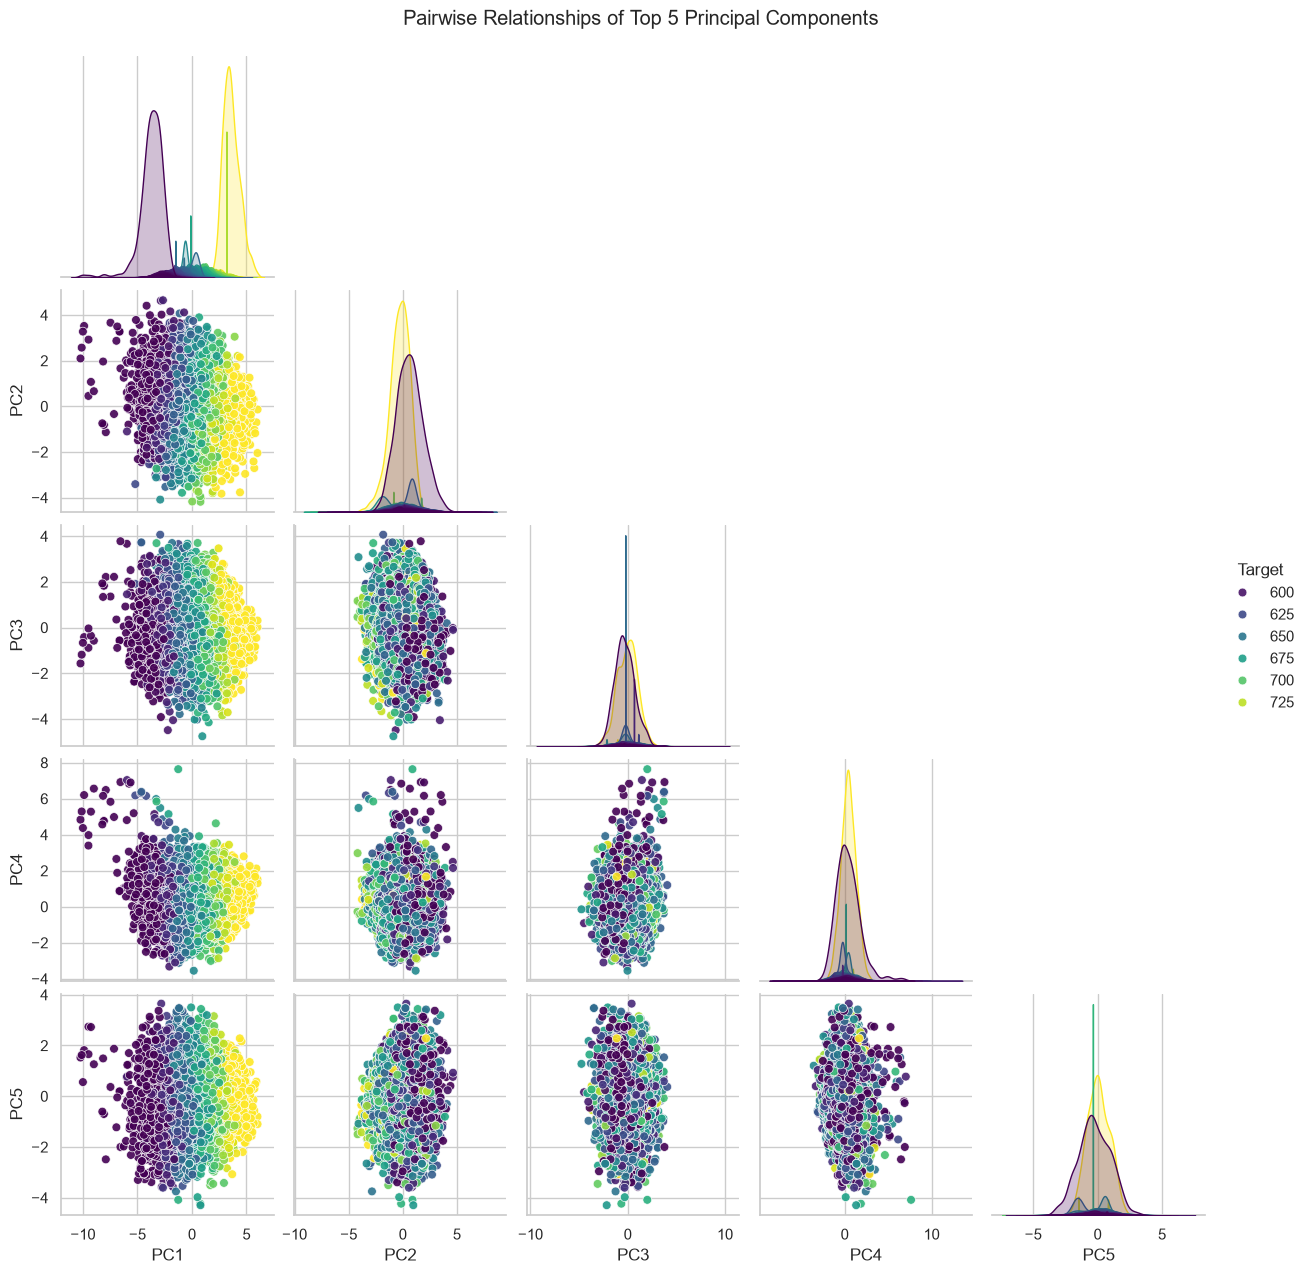

In [30]:
pca_5d = PCA(n_components=5)
components_5d = pca_5d.fit_transform(X_scaled)

# Create 5D DataFrame
df_5d = pd.DataFrame(data=components_5d, columns=['PC1', 'PC2', 'PC3', 'PC4', 'PC5'])
df_5d['Target'] = y.values

# Plot Pairplot
plt.figure(figsize=(15, 15))
# We use a pairplot to compare every PC against every other PC
sns.pairplot(df_5d, hue='Target', palette='viridis', corner=True, 
             plot_kws={'alpha': 0.9, 's': 40, 'edgecolor': 'w'})
plt.suptitle('Pairwise Relationships of Top 5 Principal Components', y=1.02)
plt.show()

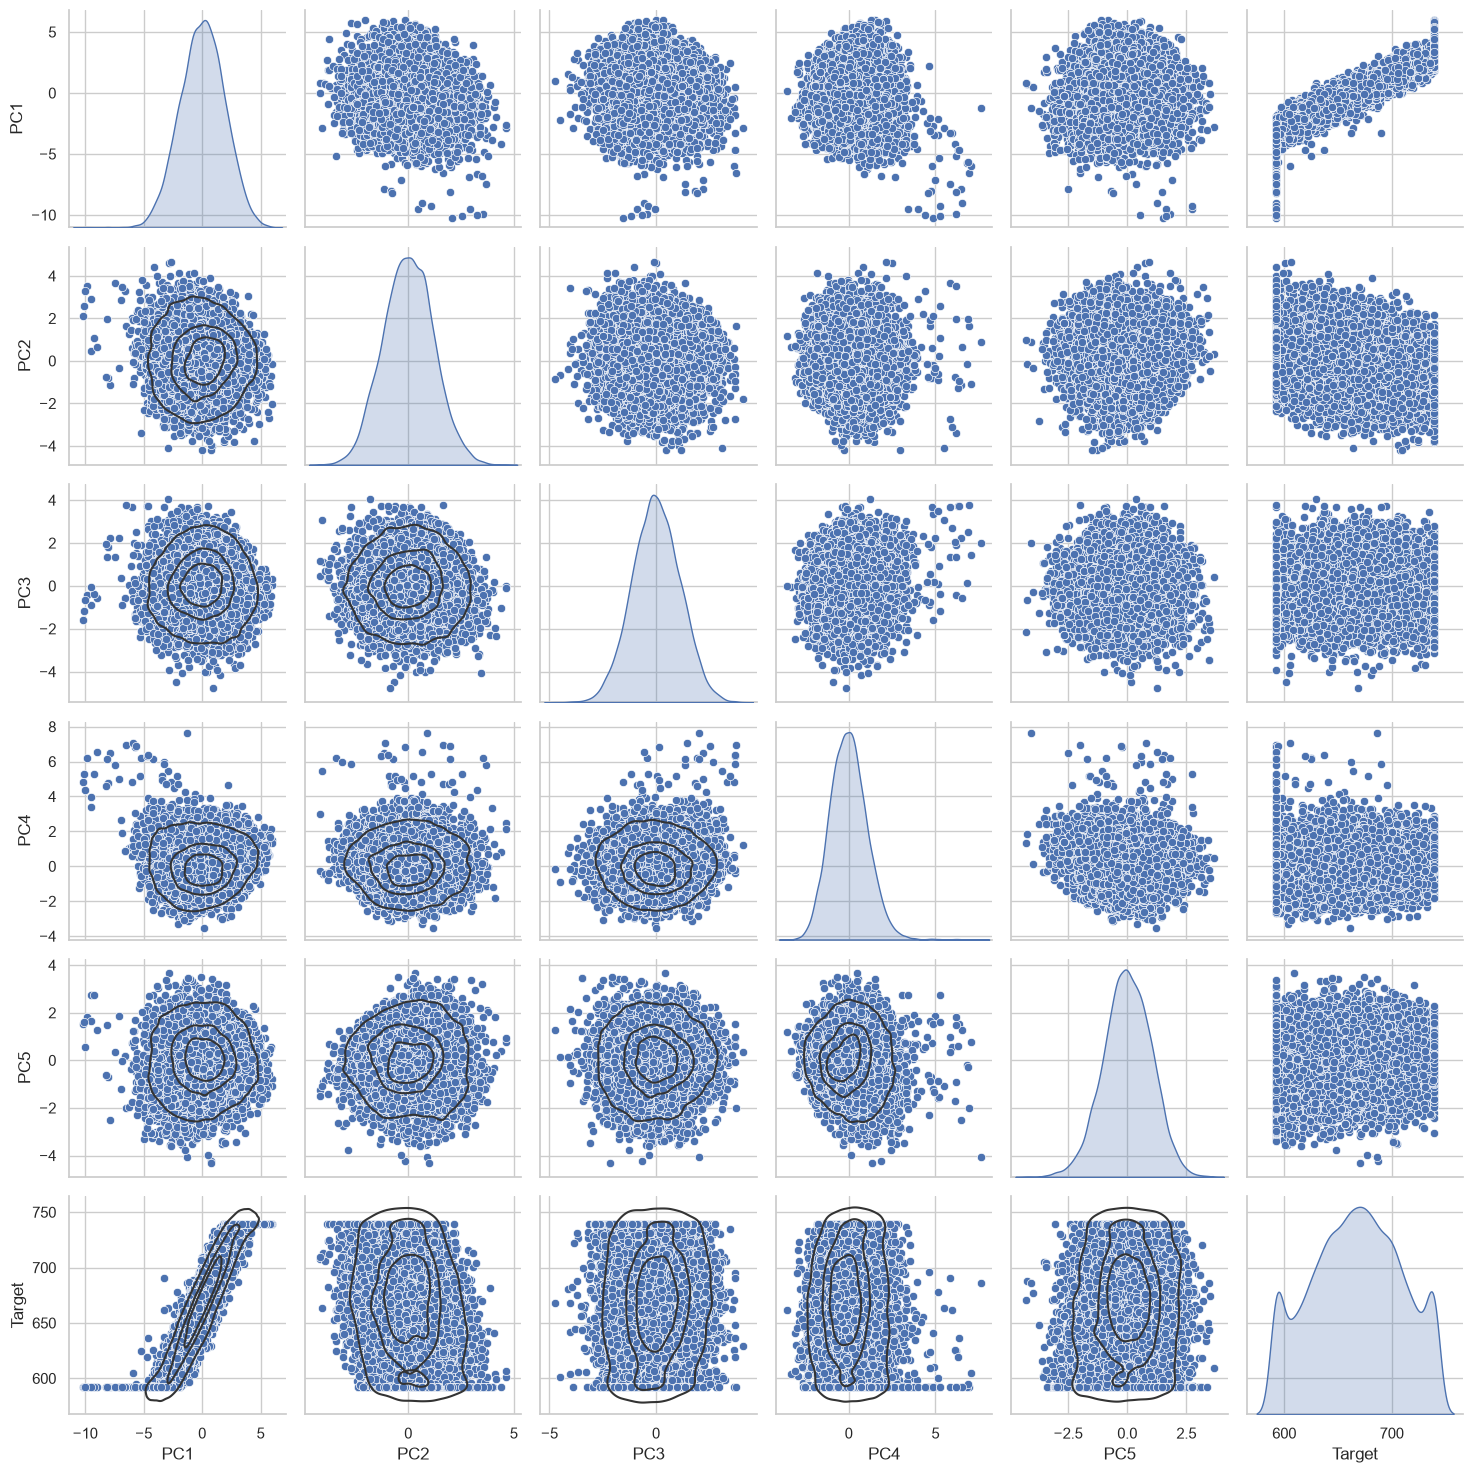

In [34]:
g = sns.pairplot(df_5d, diag_kind="kde")
g.map_lower(sns.kdeplot, levels=4, color=".2")

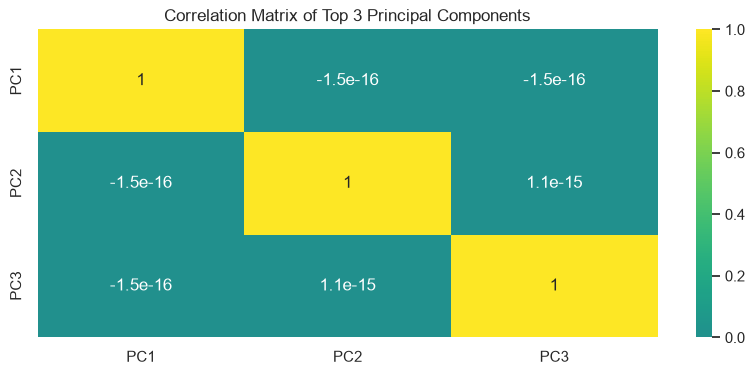

In [33]:
#plotting pca against their correlation with each other
plt.figure(figsize=(10, 4))
sns.heatmap(PCA_DF[['PC1', 'PC2', 'PC3']].corr(), annot=True, cmap='viridis', center=0)
plt.title('Correlation Matrix of Top 3 Principal Components')
plt.show()